# **Customer Churn Prediction Project**

### **Lab_Mid**
### **Submitted By**

- Awais Manzoor (SP24-BBD-026)  
- Fawad Saqib (SP24-BBD-047)  
- M. Haisam (SP24-BBD-096)

### **Problem Statement**

- Customer churn is a major problem for businesses, as losing customers reduces revenue and growth.
- The goal of this project is to build a machine learning model that can predict whether a customer will leave the bank (churn) or stay, based on their personal and account information.By identifying customers who are likely to churn, companies can take early actions to retain them and improve customer satisfaction.

###  **Import Libraries**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

## **Load Dataset**

In [5]:
df = pd.read_csv('/content/Churn_Modelling.csv')
df.sample(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9493,9494,15617657,Ts'ai,664,France,Female,36,0,103502.22,1,1,1,146191.82,0
6175,6176,15587584,Nebeuwa,503,Spain,Male,31,4,0.00,2,1,1,21645.06,0
8038,8039,15756824,Giordano,613,Germany,Female,50,5,101242.98,2,1,0,12493.61,0
3483,3484,15626412,Mort,499,Spain,Male,39,6,0.00,2,1,1,81409.00,0
1311,1312,15750497,Longo,850,France,Female,37,7,153147.75,1,1,1,152235.30,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


### **Check_Missing_Values**

In [8]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


### **Drop Irrelevant Columns**

In [9]:
df.drop(['RowNumber','CustomerId','Surname'], axis=1, inplace=True)

- Removed unnecessary columns that do not help prediction.

###  **Exploratory_Data_Analysis**

#### **Target Variable Distribution**

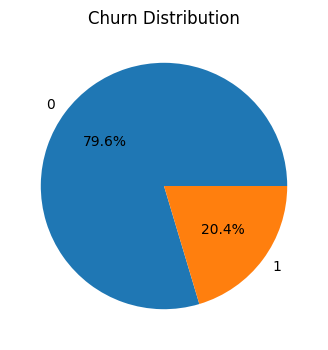

In [10]:
plt.figure(figsize=(4,4))
df['Exited'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Churn Distribution")
plt.ylabel("")
plt.show()

- The target column looks imbalanced
- so  accuracy would not be a good metric to evaluate the model and we would need to apply balancing techniques like SMOTE while modeling

#### **Numerical Features**

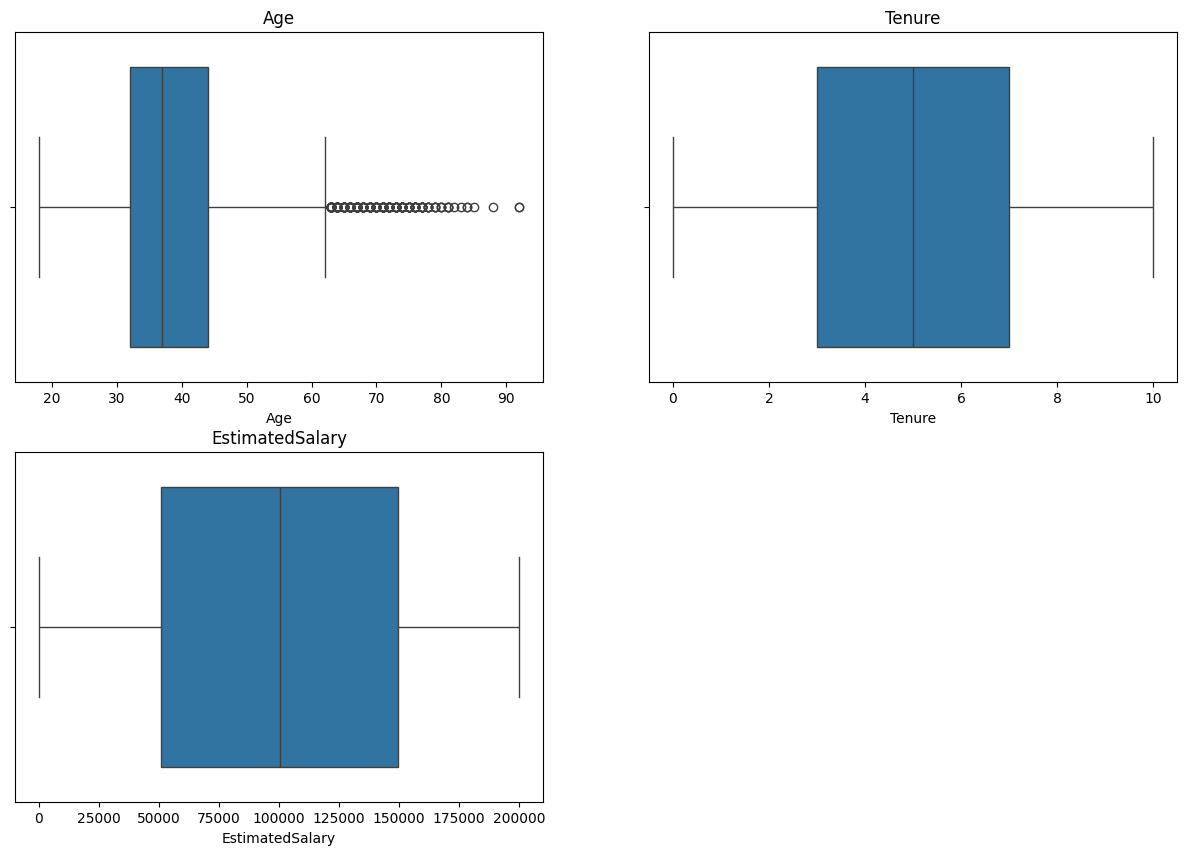

In [11]:
plt.figure(figsize=(15,10))
for i, col in enumerate(['Age','Tenure','EstimatedSalary']):
    plt.subplot(2,2,i+1)
    sns.boxplot(x=df[col])
    plt.title(col)
plt.show()

- It does not look like there are many outliers in the numerical features, except Age.So no major cleaning required

In [12]:
# Outlier treatment using IQR method
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1


In [13]:

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df['Age'] = np.clip(df['Age'], lower_bound, upper_bound)
print(f"Age range after fixing: {df['Age'].min()} to {df['Age'].max()}")

Age range after fixing: 18 to 62


#### **Categorical Features**

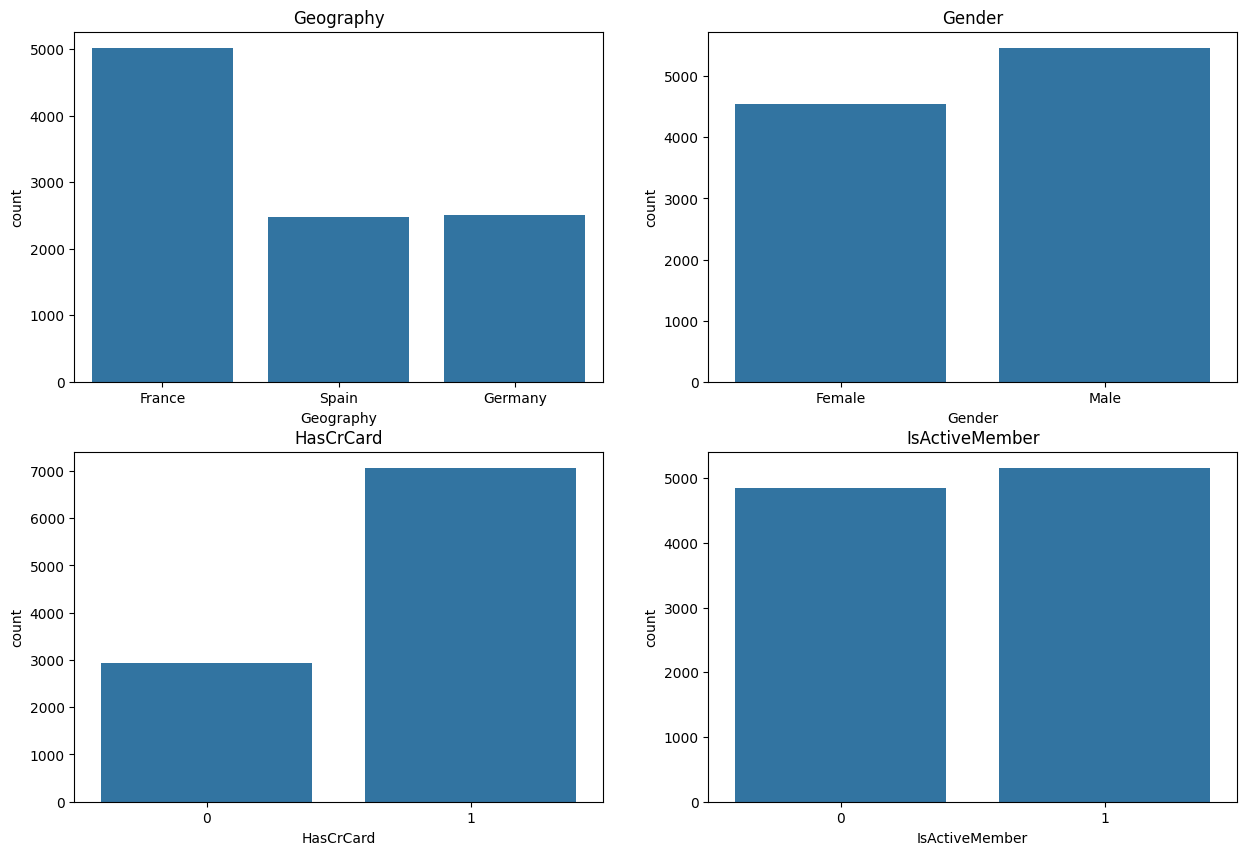

In [14]:
plt.figure(figsize=(15,10))
for i, col in enumerate(['Geography','Gender','HasCrCard','IsActiveMember']):
    plt.subplot(2,2,i+1)
    sns.countplot(x=df[col])
    plt.title(col)
plt.show()

    
- The count plots indicate that there are more customers from France than Spain or Germany,Gender almost balanced,Most customers have credit cards,Active members are slightly higher

#### **Churn**

Observing independent variables based on the Exited Column:


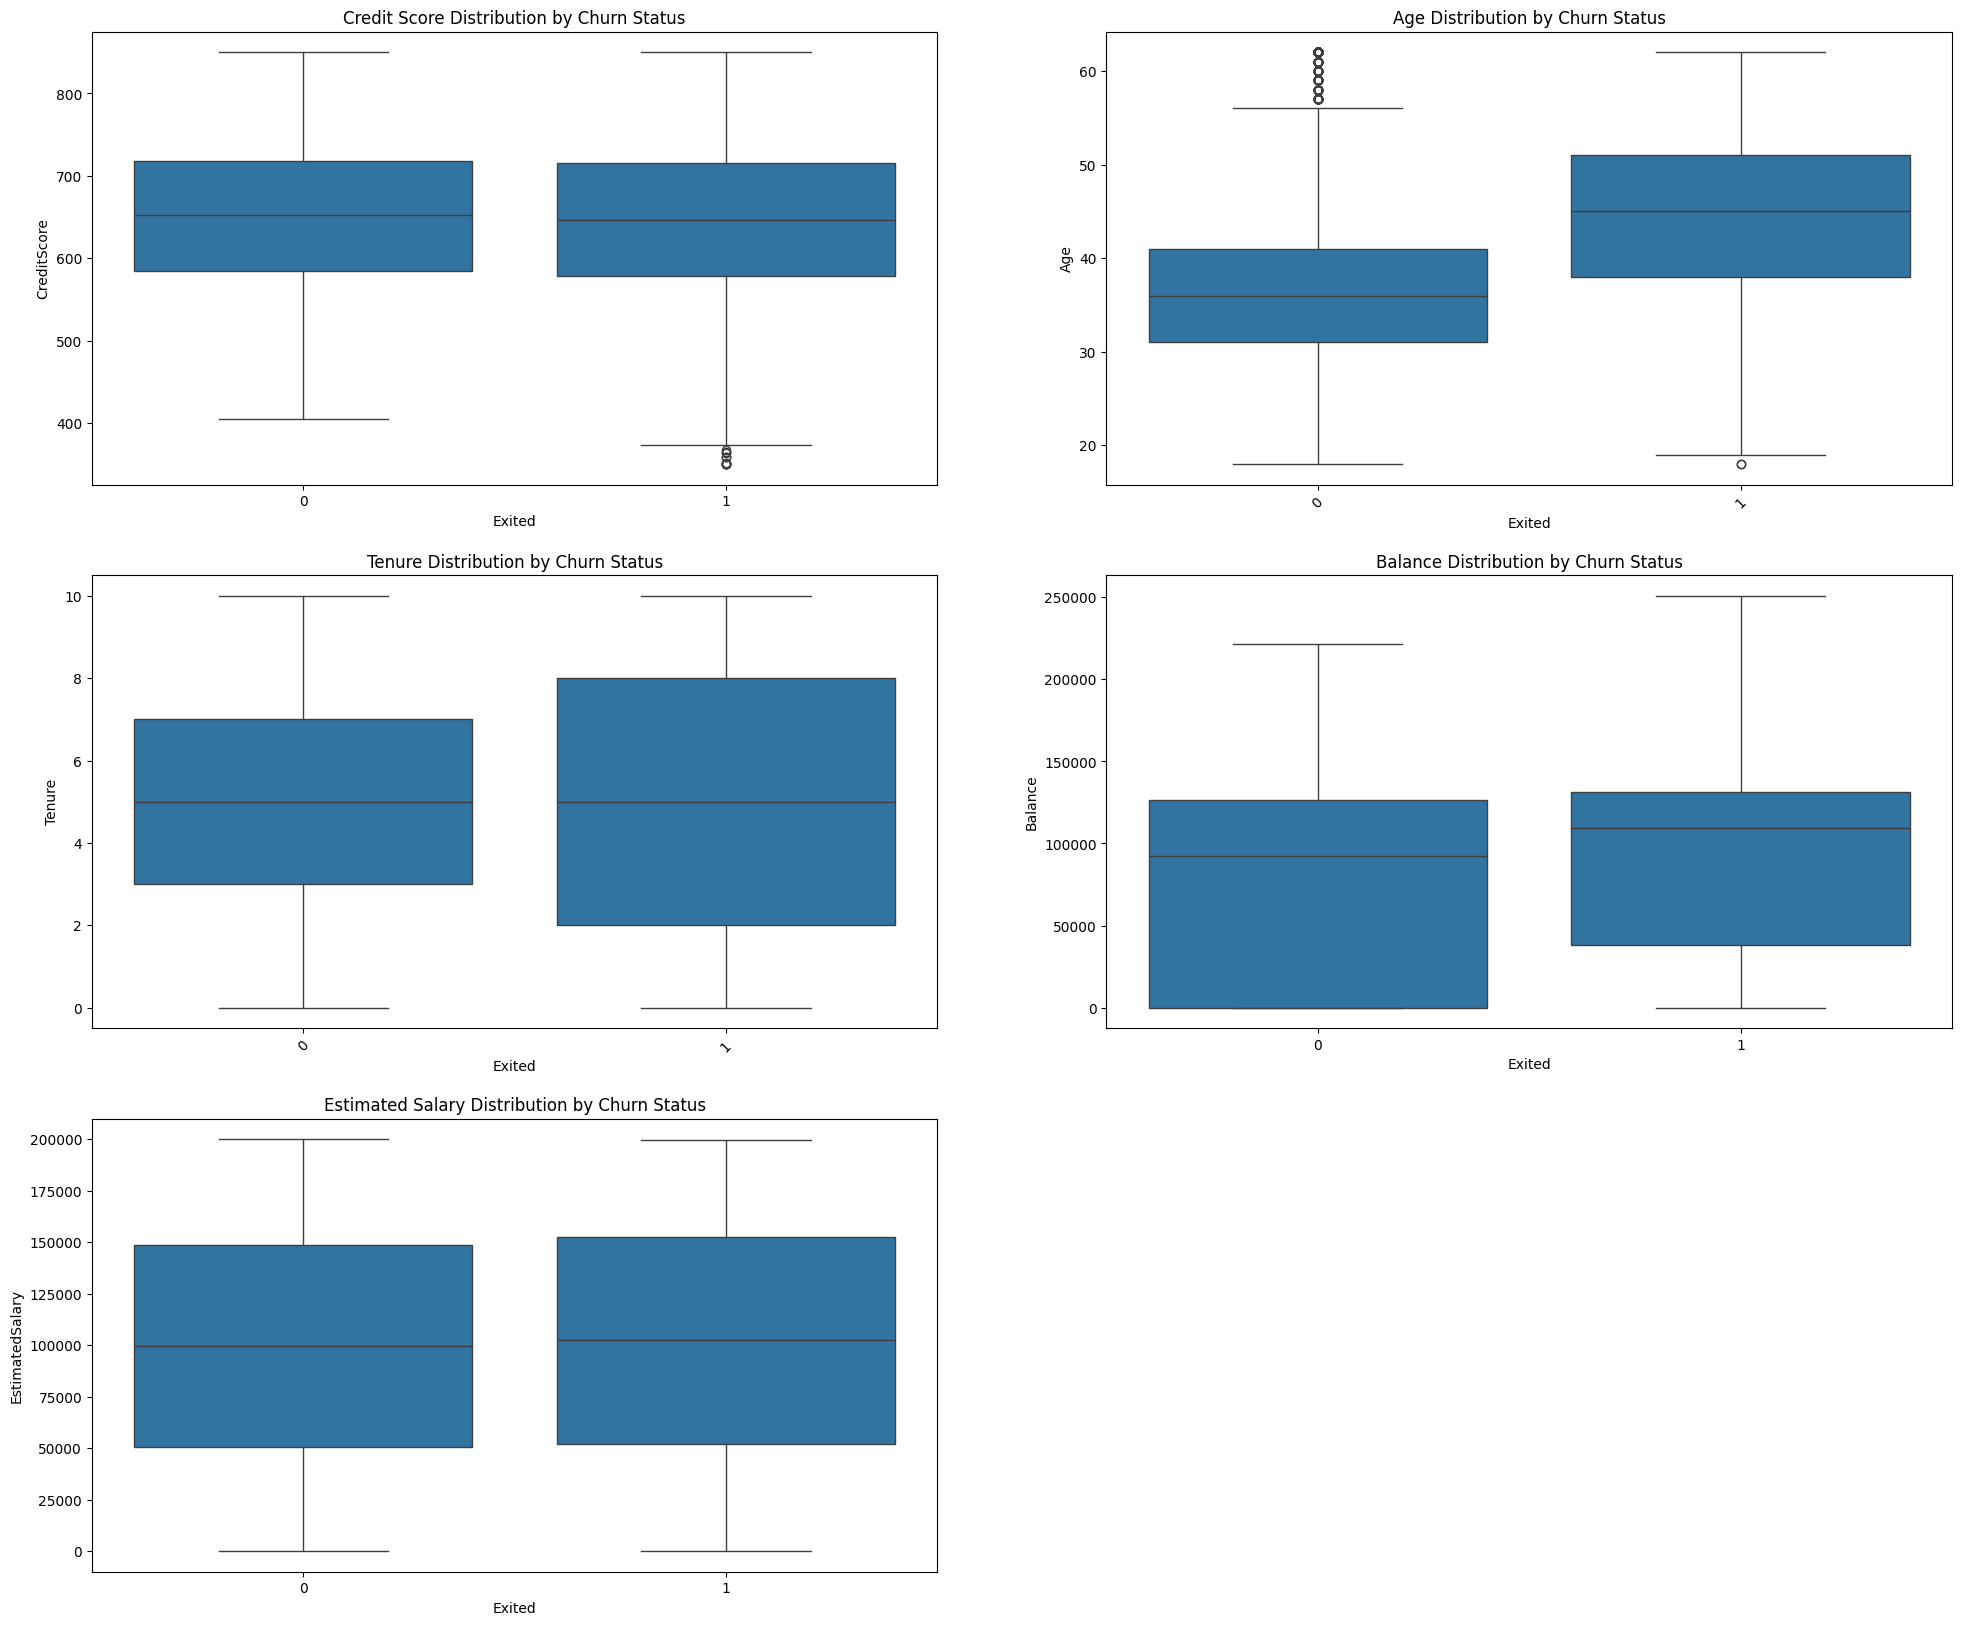

In [15]:
print("Observing independent variables based on the Exited Column:")

fig, axes = plt.subplots(3,2, figsize=(24,20))

sns.boxplot(data=df, y='CreditScore', x ='Exited',  ax=axes[0,0])
axes[0,0].set_title('Credit Score Distribution by Churn Status')

sns.boxplot(data=df, y='Age', x ='Exited', ax=axes[0,1])
axes[0,1].set_title('Age Distribution by Churn Status')
axes[0,1].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, y='Tenure', x ='Exited', ax=axes[1,0])
axes[1,0].set_title('Tenure Distribution by Churn Status')
axes[1,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=df, y='Balance', x ='Exited', ax=axes[1,1])
axes[1,1].set_title('Balance Distribution by Churn Status')

sns.boxplot(data=df, y='EstimatedSalary', x= 'Exited', ax=axes[2,0])
axes[2,0].set_title('Estimated Salary Distribution by Churn Status')

axes[2,1].axis('off')
plt.show()

- The credit score distribution does not show a stark difference, indicating that the credit score may not be a strong predictor of churn.
- The tenure distribution suggests that customers with a shorter tenure are slightly more likely to churn than those with a longer tenure.
- Age distribution shows   older customers appear more likely to churn than younger ones.
- The balance distribution is significantly different, so Customers with higher balance tend to churn more.
- The estimated salary distribution does not show a stark difference, so salary may not be a primary factor in the decision to churn.

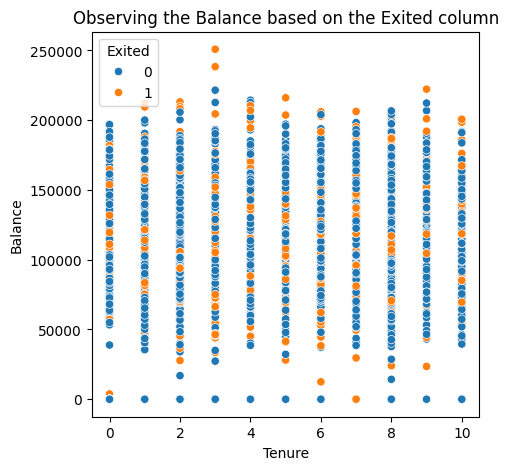

In [16]:
plt.figure(figsize=(5,5))
sns.scatterplot(x='Tenure', y='Balance', hue='Exited', data=df)
plt.title('Observing the Balance based on the Exited column')
plt.show()

-  scatter plot indicates that there is no clear pattern or correlation between tenure and balance for both churned and retained customers, implying these factors independently do not strongly predict customer churn

#### **Correlation Heatmap**

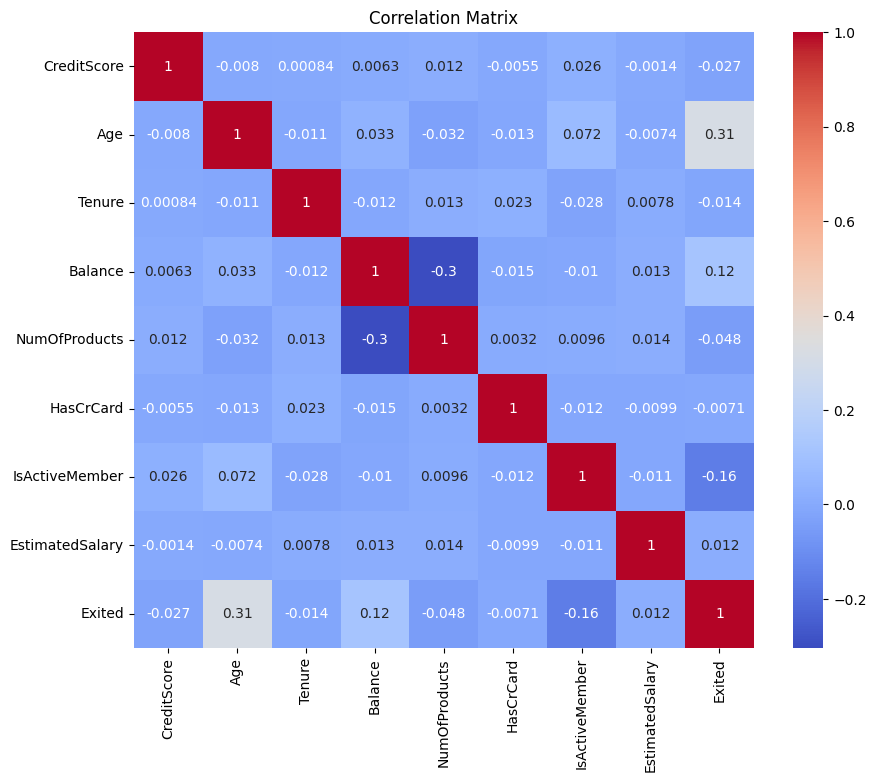

In [17]:
num_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))
sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

- Age positively correlated with churn,Active members less likely to churn and Balance has moderate effect

#### **Encoding**

In [18]:
df = pd.get_dummies(df, columns=['Geography','Gender'], drop_first=True)
df.head()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


- Converted categorical data into numbers for model training.

#### **Split Data**

In [19]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **Scaling**

In [21]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

- Scaled data so all features have equal importance.

### **Function_Evaluation**

In [22]:
def evaluate(model, name):
    y_pred = model.predict(X_test)

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    }

- calculates all required metrics for each model.

###  **Modeling**

#### **Logistic_Regression_Tuning**

In [23]:
lr1 = LogisticRegression()
lr1.fit(X_train, y_train)

lr2 = LogisticRegression(C=0.5, class_weight='balanced')
lr2.fit(X_train, y_train)

LogisticRegression(C=0.5, class_weight='balanced')

- Changed regularization and class weight to improve performance.

### **KNN_Tuning**

In [24]:
knn1 = KNeighborsClassifier(n_neighbors=5)
knn1.fit(X_train, y_train)


KNeighborsClassifier()

In [25]:

knn2 = KNeighborsClassifier(n_neighbors=11)
knn2.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=11)

- Changed number of neighbors to see effect on accuracy.

### **Decision_Tree_Tuning**

In [26]:
dt1 = DecisionTreeClassifier()
dt1.fit(X_train, y_train)

DecisionTreeClassifier()

In [27]:


dt2 = DecisionTreeClassifier(max_depth=5, min_samples_split=10)
dt2.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, min_samples_split=10)

- Limited depth to reduce overfitting.

### **SVM_Tuning**

In [28]:
svm1 = SVC(kernel='rbf')
svm1.fit(X_train, y_train)


SVC()

In [29]:

svm2 = SVC(kernel='linear', C=0.1)
svm2.fit(X_train, y_train)

SVC(C=0.1, kernel='linear')

- Tried different kernels to compare performance.

### **Compare All Models**

In [30]:
results = []

results.append(evaluate(lr1, "LR Default"))
results.append(evaluate(lr2, "LR Tuned"))

results.append(evaluate(knn1, "KNN k=5"))
results.append(evaluate(knn2, "KNN k=11"))

results.append(evaluate(dt1, "DT Default"))
results.append(evaluate(dt2, "DT Tuned"))

results.append(evaluate(svm1, "SVM RBF"))
results.append(evaluate(svm2, "SVM Linear"))

results_df = pd.DataFrame(results)
results_df

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1
0,LR Default,0.8165,0.582278,0.234097,0.333938
1,LR Tuned,0.7240,0.391542,0.730280,0.509769
2,KNN k=5,0.8310,0.618026,0.366412,0.460064
3,KNN k=11,0.8375,0.675258,0.333333,0.446337
4,DT Default,0.7775,0.441441,0.498728,0.468339
5,DT Tuned,0.8560,0.758621,0.391858,0.516779
6,SVM RBF,0.8575,0.781250,0.381679,0.512821
7,SVM Linear,0.8035,0.000000,0.000000,0.000000


- The Tuned Decision Tree is the best-performing model as it achieves the highest accuracy (85.75%) and the best F1-Score (0.521), successfully balancing precision and recall while correcting the overfitting seen in the default version.

### **Best Model**

In [31]:
best_model = results_df.sort_values(by='F1', ascending=False)
best_model

,Model,Accuracy,Precision,Recall,F1
5,DT Tuned,0.8560,0.758621,0.391858,0.516779
6,SVM RBF,0.8575,0.781250,0.381679,0.512821
1,LR Tuned,0.7240,0.391542,0.730280,0.509769
4,DT Default,0.7775,0.441441,0.498728,0.468339
2,KNN k=5,0.8310,0.618026,0.366412,0.460064
3,KNN k=11,0.8375,0.675258,0.333333,0.446337
0,LR Default,0.8165,0.582278,0.234097,0.333938
7,SVM Linear,0.8035,0.000000,0.000000,0.000000


- Model with highest F1-score is selected as best. so which one is DT Tuned

### **Confusion Matrix**

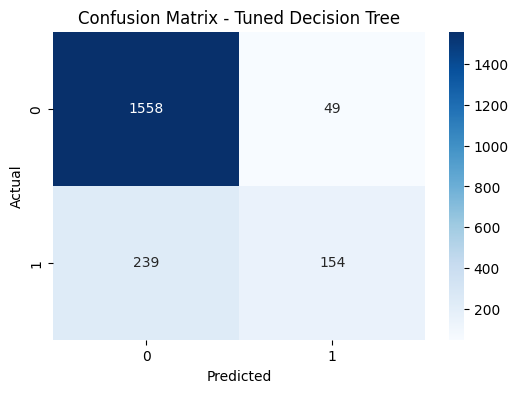

In [32]:
best = dt2

y_pred = best.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Visualization
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - Tuned Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

- True Negatives (1560): Correctly predicted non-churn customers  
- False Positives (47): Predicted churn but actually not churn  
- False Negatives (238): Missed churn customers (important error)  
- True Positives (155): Correctly predicted churn customers  
The model performs well in identifying non-churn customers, but it misses some churn cases 238 which should be reduced